## <u> ASSIGNMENT 3 : PRINCIPAL COMPONENT ANALYSIS </u>

### Question 2  :
*  Yale faces data set is an image data set of 15 subjects that is used for testing
facial recognition methods. There are six different grayscale images of each
subject with different facial expressions. The resolution of each image is 243 x
320 pixels.

In [89]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os 

* Convert  each  image  into  a  column  vector  of  size  77760  x  1  by  stacking  the columns  of  the  digital  image  one  below  the  other  (also  known  as  the  vec operation  on  a  matrix).    
* Using  the  normal  images  of  each  subject  as  the standard,  determine  how  many  of  the  other  images  you  are  able  to  correctly identify by using Euclidean distance between the image and the standard images.

In [90]:
vals = os.listdir(r'yalefaces')
vals.sort()

In [91]:
data = np.zeros((77760,1))
for name in vals :
    filename = 'yalefaces/' + name
    img = Image.open(filename)
    img_vec = np.array(img).T.reshape((77760,1))
    data = np.append(data, img_vec, axis=1 )
    
    # plt.imshow(img_vec.reshape((320,243)))
    # plt.show()

data = np.delete(data, obj=0, axis=1)
np.shape(data)

(77760, 90)

In [92]:
data
xaxs = [ i for i in range(90)]

In [93]:
count = 0
for i in range(0,90,6) : 
    c = 0
    # print(np.abs((data[:,i:i+5] - data[:,[i+5]])).sum(axis=0))
    euclidean_dist = np.abs((data - data[:,[i+5]])).sum(axis=0)
    minimum_dist   = np.argsort(euclidean_dist)[0:6]
    print(np.argsort(euclidean_dist)[0:6])
    for distance in minimum_dist :
        if distance <= i+5 and distance >= i:
            count += 1
            c += 1
    # plt.stem(xaxs,euclidean_dist,markerfmt='.')
    # plt.axvline(xaxs[i+5], color='red')
    # plt.axvline(xaxs[i], color='red')
    # plt.show()
    print(c)

print(count)

[ 5  1  2  0 24 18]
4
[10 11  8  7  6 67]
5
[17 16 14 89 41 40]
3
[23 20 19 22 18 10]
5
[29 28 26 25 24 68]
5
[34 35 32 31 78 79]
4
[41 40 37 38 14 17]
4
[47 43 42 44 89 14]
4
[53 52 50 44 37 89]
3
[59 58 56 36 46 84]
3
[65 61 62 60 64  0]
5
[71 70 67  8 69 11]
4
[77 74 73 76 12 72]
5
[83 82 79 80 78 30]
5
[89 17 16 84 14 47]
2
61


* Perform a PCA of the normal images (each subject is a sample) and use % variance  captured  for  choosing  the  number  of  PCs.    Instead  of  storing  the images,  the  scores  of  the  retained  PCs  for  each  standard  image  can  be  stored  (leading  to  substantial  reduction  in  storage).    
* Determine  how  many  of  the  other images you are able to correctly classify based on comparison of the compressed images scores (use Euclidean distance between the score vectors).  
* Vary the number of PCs chosen to find out the optimal number of PCs that gives the best classification accuracy. 

In [94]:
normal_img = np.zeros((77760,1))
for i in range(5,90,6) :
    normal_img = np.append(normal_img, data[:,[i]], axis=1)

In [95]:
normal_img = np.delete(normal_img, obj=0, axis=1)

In [96]:
normal_img_mean = normal_img.mean(axis=0)
normal_img = (normal_img - normal_img_mean)/(77760**0.5)

In [97]:
from scipy.linalg import svd

In [98]:
s,v,d = svd(normal_img, full_matrices=False)

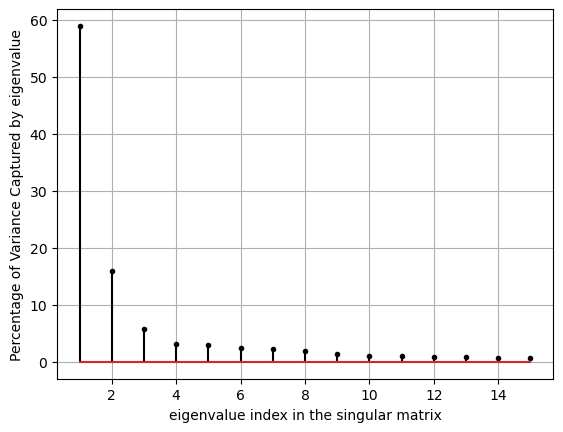

In [99]:
xaxh = [ i for i in range(1,16,1) ]
eigvals = v**2
plt.stem(xaxh, eigvals/eigvals.sum()*100, linefmt='black', markerfmt='.')
plt.xlabel('eigenvalue index in the singular matrix')
plt.ylabel('Percentage of Variance Captured by eigenvalue')
plt.grid()

In [100]:
eigvals[0:10].sum()/eigvals.sum() * 100

95.84296621138503

#### Using N eigenvectors Computed from the SVD of the Data Matrix to calculate the scores of all the 90 images

In [101]:
N = 15

* Computes the scores and the reconstructed version of the normal images

In [102]:
scores = normal_img.T@s[:,0:N]
reconstruced_images = scores@s[:,0:N].T

* Computes the scores and the reconstructed version of all the data
* Only the scores are of interest for this assignment 
* The reconstructed values are used for visualizing the PCA Process

In [103]:
data_mean = normal_img_mean.repeat(6)

In [104]:
data_scores = (data-data_mean).T@s[:,0:N]
reconstruced_data = data_scores@s[:,0:N].T

In [105]:
identified_images = 0

for i in range(0,90,6) : 
    euclidean_dist_scores = np.abs((data_scores.T - data_scores.T[:,[i+5]])).sum(axis=0)
    minimum_dist_scores   = np.argsort(euclidean_dist_scores)[0:6]
    for distance in minimum_dist_scores :
        if distance <= i+5 and distance >= i:
            identified_images += 1

In [106]:
print("Number of images Identified from the PCA Scores :", identified_images )
print("Number of images identified from the euclidean distance of data :", count)

Number of images Identified from the PCA Scores : 65
Number of images identified from the euclidean distance of data : 61


In [107]:
# For printing the reconstructed Normal images
# for i in range(15) :
    # plt.imshow(reconstruced_images[i].reshape((320,243)).T)
    # plt.show()

# For printing all the reconstructed images 
# for recon in reconstruced_data :
    # plt.imshow(recon.reshape((320,243)).T)
    # plt.show()

In [108]:
x = [ i for i in range(1,16) ]
y = []

for n in range(1,16) :

    data_scores = data.T@s[:,0:n]
    reconstruced_data = data_scores@s[:,0:n].T

    identified_images = 0

    for i in range(0,90,6) : 
        euclidean_dist_scores = np.abs((data_scores.T - data_scores.T[:,[i+5]])).sum(axis=0)
        minimum_dist_scores   = np.argsort(euclidean_dist_scores)[0:6]
        for distance in minimum_dist_scores :
            if distance <= i+5 and distance >= i:
                identified_images += 1

    print("Number of images Identified from the PCA Scores :", identified_images , "and Number of eigenvectors used :", n)
    y.append(identified_images)

Number of images Identified from the PCA Scores : 36 and Number of eigenvectors used : 1
Number of images Identified from the PCA Scores : 44 and Number of eigenvectors used : 2
Number of images Identified from the PCA Scores : 45 and Number of eigenvectors used : 3
Number of images Identified from the PCA Scores : 50 and Number of eigenvectors used : 4
Number of images Identified from the PCA Scores : 55 and Number of eigenvectors used : 5
Number of images Identified from the PCA Scores : 55 and Number of eigenvectors used : 6
Number of images Identified from the PCA Scores : 57 and Number of eigenvectors used : 7
Number of images Identified from the PCA Scores : 57 and Number of eigenvectors used : 8
Number of images Identified from the PCA Scores : 55 and Number of eigenvectors used : 9
Number of images Identified from the PCA Scores : 59 and Number of eigenvectors used : 10
Number of images Identified from the PCA Scores : 61 and Number of eigenvectors used : 11
Number of images Id

Text(0.5, 1.0, 'Variation of Images Identifed with number of eigenvectors')

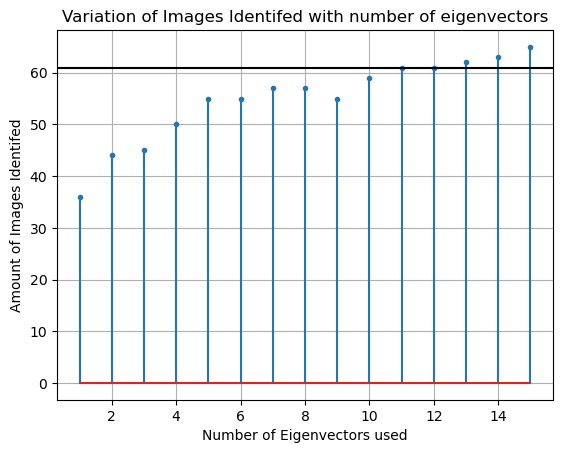

In [109]:
plt.stem(x,y,markerfmt='.')
plt.axhline(count, color='black')
plt.ylabel('Amount of Images Identifed')
plt.xlabel('Number of Eigenvectors used')
plt.grid()
plt.title('Variation of Images Identifed with number of eigenvectors')